In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install -q --upgrade transformers==4.45.2 accelerate sentencepiece huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 61.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 83.4 MB/s eta 0:00:00:00:01


In [2]:
import os
import re
import gc
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

import torch
from transformers import AutoProcessor, PaliGemmaForConditionalGeneration
from huggingface_hub import login, whoami, hf_hub_download
from kaggle_secrets import UserSecretsClient

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

CSV_PATH = "/kaggle/working/vqa_dataset_test_mapped.csv"
OUTPUT_DIR = "/kaggle/working/vlm_day_night_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAMPLE_PER_CATEGORY_PER_LIGHT = 100
PALIGEMMA_MODEL_ID = "google/paligemma-3b-mix-224"

print("DEVICE:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

2026-04-18 14:52:27.719803: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776523947.939185      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776523948.004686      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776523948.516223      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776523948.516264      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776523948.516266      55 computation_placer.cc:177] computation placer alr

DEVICE: cuda
GPU: Tesla T4


In [3]:
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("hf_token")

login(token=hf_token)

print("Logged in to Hugging Face")
print(whoami())

Logged in to Hugging Face
{'type': 'user', 'id': '69e314a71a4c8568d7217521', 'name': 'limousine', 'fullname': 'VISHAL', 'email': 'vk0366917@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1777593600, 'isPro': False, 'avatarUrl': '/avatars/4c420155fa649c282a32ce40c8592211.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'okay', 'role': 'read', 'createdAt': '2026-04-18T13:44:41.169Z'}}}


In [4]:
path = hf_hub_download(
    repo_id=PALIGEMMA_MODEL_ID,
    filename="config.json",
    token=hf_token
)

print("PaliGemma access approved")
print(path)

config.json: 0.00B [00:00, ?B/s]

PaliGemma access approved
/root/.cache/huggingface/hub/models--google--paligemma-3b-mix-224/snapshots/d1d8734c9c3ad0ccfeea4afc270faa356c2ba515/config.json


In [5]:
if not os.path.exists("/kaggle/working/roadscapes_data"):
    !git clone https://github.com/roadscapes/roadscapes_data.git /kaggle/working/roadscapes_data

csv_path = "/kaggle/working/roadscapes_data/vqa_dataset_test.csv"
image_root = Path("/kaggle/working/roadscapes_data/image_data/images")

image_index = {}
for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
    for path in image_root.rglob(ext):
        image_index[path.name] = str(path)

print("Indexed images:", len(image_index))

df_map = pd.read_csv(csv_path)
print("CSV rows:", len(df_map))
print("Columns:", df_map.columns.tolist())

possible_cols = ["filename", "image", "image_name", "img", "image_path", "Image"]
image_col = None

for col in possible_cols:
    if col in df_map.columns:
        image_col = col
        break

if image_col is None:
    raise ValueError(f"No image column found. Available columns: {df_map.columns.tolist()}")

print("Using image column:", image_col)

df_map["full_image_path"] = df_map[image_col].astype(str).apply(
    lambda x: image_index.get(os.path.basename(x.strip()), None)
)

print("Matched rows:", df_map["full_image_path"].notna().sum())

df_map.to_csv(CSV_PATH, index=False)
print("Saved:", CSV_PATH)

Cloning into '/kaggle/working/roadscapes_data'...
remote: Enumerating objects: 26996, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 26996 (delta 8), reused 12 (delta 1), pack-reused 26971 (from 2)
Receiving objects: 100% (26996/26996), 1.57 GiB | 51.38 MiB/s, done.
Resolving deltas: 100% (17147/17147), done.
Updating files: 100% (26960/26960), done.
Indexed images: 8979
CSV rows: 13209
Columns: ['filename', 'category', 'question', 'answer']
Using image column: filename
Matched rows: 13209
Saved: /kaggle/working/vqa_dataset_test_mapped.csv


In [6]:
df = pd.read_csv(CSV_PATH)

required_cols = ["filename", "question", "answer", "category", "full_image_path"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df = df[df["full_image_path"].notna()].copy()
df = df[df["full_image_path"].apply(lambda x: os.path.exists(str(x)))].copy()

def normalize_category(cat):
    c = str(cat).strip().lower().replace("_", " ")
    if "count" in c:
        return "Object Counting"
    if "surround" in c:
        return "Surrounding Description"
    if "description" in c:
        return "Object Description"
    return str(cat)

def get_light(filename):
    return "night" if "night" in str(filename).lower() else "day"

df["category_std"] = df["category"].apply(normalize_category)
df["light"] = df["filename"].apply(get_light)

target_categories = [
    "Object Counting",
    "Object Description",
    "Surrounding Description"
]

df = df[df["category_std"].isin(target_categories)].copy()
df = df[df["light"].isin(["day", "night"])].copy()

print("Rows:", len(df))
print(df["light"].value_counts())
print(df["category_std"].value_counts())

Rows: 10311
light
day      8939
night    1372
Name: count, dtype: int64
category_std
Object Counting            4419
Object Description         2946
Surrounding Description    2946
Name: count, dtype: int64


In [7]:
sampled_splits = {}

for cat in target_categories:
    for light in ["day", "night"]:
        subset = df[(df["category_std"] == cat) & (df["light"] == light)].copy()

        if len(subset) == 0:
            continue

        sample_n = min(SAMPLE_PER_CATEGORY_PER_LIGHT, len(subset))
        sampled = subset.sample(n=sample_n, random_state=SEED)

        sampled_splits[(cat, light)] = sampled.reset_index(drop=True)
        print(f"{cat} | {light}: {len(sampled)} samples")

Object Counting | day: 100 samples
Object Counting | night: 100 samples
Object Description | day: 100 samples
Object Description | night: 100 samples
Surrounding Description | day: 100 samples
Surrounding Description | night: 100 samples


In [9]:
def is_yes_no_question(question: str) -> bool:
    q = str(question).strip().lower()
    return q.startswith("is ") or q.startswith("are ") or " more " in q

def build_prompt(category: str, light: str, question: str) -> str:
    q = str(question).strip()

    if category == "Object Counting":
        if is_yes_no_question(q):
            return f"""Look at the road image carefully.

Lighting: {light}

Rules:
- Answer only Yes or No.
- No explanation.
- No extra words.

Question: {q}"""
        else:
            return f"""Look at the road image carefully.

Lighting: {light}

Rules:
- Count the requested object carefully.
- Answer with only one integer number.
- No words.
- No explanation.
- If not visible, answer 0.

Question: {q}"""

    if category == "Object Description":
        return f"""Look at the road image carefully.

Lighting: {light}

Rules:
- Answer in 1 to 3 words only.
- No explanation.
- No sentence.

Question: {q}"""

    return f"""Look at the road image carefully.

Lighting: {light}

Rules:
- Answer in 2 to 6 words only.
- Briefly describe the surroundings.
- No explanation.
- No full sentence.

Question: {q}"""

def clean_prediction(text: str, question: str = "", category: str = "") -> str:
    text = str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)

    for bad in ["there are", "there is", "it is", ".", ",", ":", ";"]:
        text = text.replace(bad, "")

    text = text.strip()

    if is_yes_no_question(question):
        if "yes" in text:
            return "yes"
        if "no" in text:
            return "no"

    if category == "Object Counting" and not is_yes_no_question(question):
        nums = re.findall(r"\d+", text)
        if nums:
            return nums[0]

    return text.strip()

def extract_first_number(text: str):
    m = re.search(r"\d+", str(text))
    return m.group(0) if m else None

def normalized_correct(pred: str, gt: str, category: str, question: str = "") -> bool:
    pred = clean_prediction(pred, question, category)
    gt = clean_prediction(gt, question, category)

    if pred.startswith("error:"):
        return False

    if category == "Object Counting":
        if is_yes_no_question(question):
            return pred == gt
        else:
            p = extract_first_number(pred)
            g = extract_first_number(gt)
            return p is not None and g is not None and p == g

    if pred == gt:
        return True
    if gt in pred or pred in gt:
        return True

    pred_words = set(pred.split())
    gt_words = set(gt.split())
    return len(pred_words & gt_words) >= 1

def validate_question(q: str) -> bool:
    return isinstance(q, str) and len(q.strip()) > 0

In [14]:
def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [15]:
def load_paligemma():
    processor = AutoProcessor.from_pretrained(PALIGEMMA_MODEL_ID)

    model = PaliGemmaForConditionalGeneration.from_pretrained(
        PALIGEMMA_MODEL_ID,
        torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
        low_cpu_mem_usage=True
    ).to(DEVICE)

    model.eval()
    return processor, model

In [16]:
def query_paligemma(processor, model, image_path, prompt, category="Object Counting"):
    try:
        image = Image.open(image_path).convert("RGB")
        image = image.resize((224, 224))

        short_prompt = prompt.split("Question:")[-1].strip()

        inputs = processor(
            text=short_prompt,
            images=image,
            return_tensors="pt"
        )

        inputs = {
            k: v.to(DEVICE) if hasattr(v, "to") else v
            for k, v in inputs.items()
        }

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=12,
                do_sample=False
            )

        pred = processor.batch_decode(outputs, skip_special_tokens=True)[0].strip().lower()
        return clean_prediction(pred, short_prompt, category)

    except Exception as e:
        return f"ERROR: {e}"

In [17]:
clear_memory()
paligemma_processor, paligemma_model = load_paligemma()
print("PaliGemma loaded")

preprocessor_config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.26M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

...

model-00003-of-00003.safetensors:   0%|          | 0.00/1.74G [00:00<?, ?B/s]

`config.hidden_act` is ignored, you should use `config.hidden_activation` instead.
Gemma's activation function will be set to `gelu_pytorch_tanh`. Please, use
`config.hidden_activation` if you want to override this behaviour.
See https://github.com/huggingface/transformers/pull/29402 for more details.


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

PaliGemma loaded


In [18]:
test_row = sampled_splits[("Object Counting", "day")].iloc[0]

test_prompt = build_prompt("Object Counting", "day", test_row["question"])

pred = query_paligemma(
    paligemma_processor,
    paligemma_model,
    test_row["full_image_path"],
    test_prompt,
    "Object Counting"
)

print("Question:", test_row["question"])
print("Ground truth:", test_row["answer"])
print("Prediction:", pred)
print("Correct:", normalized_correct(pred, test_row["answer"], "Object Counting", test_row["question"]))

Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)


Question: How many objects of type car are in the image?
Ground truth: 5
Prediction: 2
Correct: False


In [19]:
paligemma_results = []

for category in target_categories:
    for light in ["day", "night"]:
        part = sampled_splits[(category, light)].copy()

        print(f"\nRunning PaliGemma | {category} | {light} | samples = {len(part)}")

        for _, row in tqdm(part.iterrows(), total=len(part), desc=f"{category}-{light}"):
            question = row["question"]
            gt = row["answer"]
            image_path = row["full_image_path"]

            if not validate_question(question):
                continue

            prompt = build_prompt(category, light, question)

            pred = query_paligemma(
                paligemma_processor,
                paligemma_model,
                image_path,
                prompt,
                category
            )

            paligemma_results.append({
                "model": "paligemma",
                "category": category,
                "light": light,
                "filename": row["filename"],
                "question": question,
                "ground_truth": gt,
                "prediction": pred,
                "is_correct": normalized_correct(pred, gt, category, question)
            })

paligemma_results_df = pd.DataFrame(paligemma_results)

print("Total evaluated:", len(paligemma_results_df))
print(paligemma_results_df.head())


Running PaliGemma | Object Counting | day | samples = 100


Object Counting-day:   0%|          | 0/100 [00:00<?, ?it/s]


Running PaliGemma | Object Counting | night | samples = 100


Object Counting-night:   0%|          | 0/100 [00:00<?, ?it/s]


Running PaliGemma | Object Description | day | samples = 100


...


Running PaliGemma | Surrounding Description | day | samples = 100


Surrounding Description-day:   0%|          | 0/100 [00:00<?, ?it/s]


Running PaliGemma | Surrounding Description | night | samples = 100


Surrounding Description-night:   0%|          | 0/100 [00:00<?, ?it/s]

Total evaluated: 600
       model         category light                        filename  \
0  paligemma  Object Counting   day  Sequence_Day_18_frame_1890.jpg   
1  paligemma  Object Counting   day   Sequence_Day_14_frame_540.jpg   
2  paligemma  Object Counting   day  Sequence_Day_18_frame_5190.jpg   
3  paligemma  Object Counting   day  Sequence_Day_18_frame_2490.jpg   
4  paligemma  Object Counting   day     Sequence_Day_8_frame_30.jpg   

                                           question ground_truth prediction  \
0    How many objects of type car are in the image?            5          2   
1    How many objects of type car are in the image?            2          1   
2                  Are there more car's than car's?           No         no   
3           Are there more car's than motorcycle's?          Yes        yes   
4  How many objects of type truck are in the image?            1          1   

   is_correct  
0       False  
1       False  
2        True  
3        True

In [20]:
paligemma_summary = (
    paligemma_results_df
    .groupby(["category", "light"])["is_correct"]
    .mean()
    .reset_index()
)

paligemma_summary["accuracy_percent"] = (paligemma_summary["is_correct"] * 100).round(2)

print(paligemma_summary)

os.makedirs(OUTPUT_DIR, exist_ok=True)

paligemma_results_df.to_csv(os.path.join(OUTPUT_DIR, "paligemma_results.csv"), index=False)
paligemma_summary.to_csv(os.path.join(OUTPUT_DIR, "paligemma_accuracy.csv"), index=False)

print("Saved files:")
print(os.listdir(OUTPUT_DIR))

                  category  light  is_correct  accuracy_percent
0          Object Counting    day        0.74              74.0
1          Object Counting  night        0.74              74.0
2       Object Description    day        0.11              11.0
3       Object Description  night        0.09               9.0
4  Surrounding Description    day        0.56              56.0
5  Surrounding Description  night        0.16              16.0
Saved files:
['paligemma_results.csv', 'paligemma_accuracy.csv']


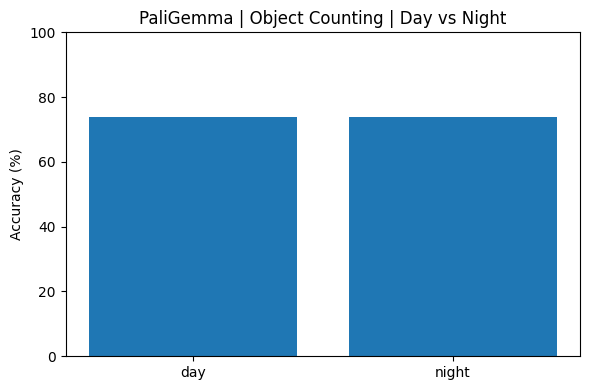

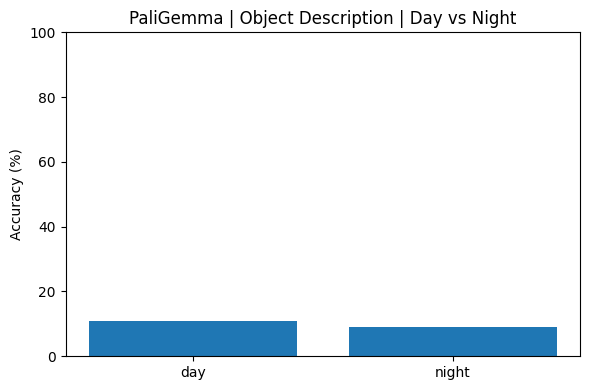

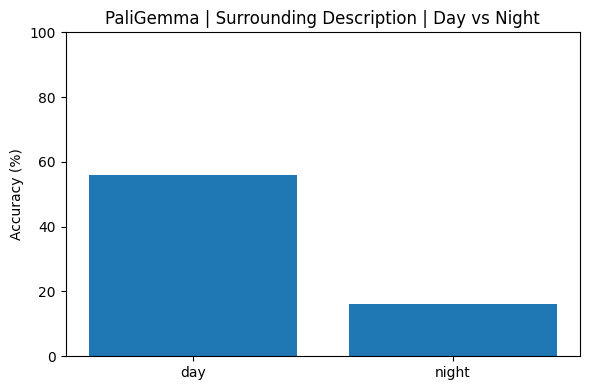

PaliGemma charts saved


In [21]:
for category in target_categories:
    sub = paligemma_summary[paligemma_summary["category"] == category].copy()

    lights = sub["light"].tolist()
    scores = sub["accuracy_percent"].tolist()

    plt.figure(figsize=(6, 4))
    plt.bar(lights, scores)
    plt.title(f"PaliGemma | {category} | Day vs Night")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 100)
    plt.tight_layout()

    out_png = os.path.join(
        OUTPUT_DIR,
        f"paligemma_{category.replace(' ', '_').lower()}_day_night.png"
    )
    plt.savefig(out_png, dpi=200)
    plt.show()

print("PaliGemma charts saved")

In [22]:
print("Files in result folder:")
print(os.listdir(OUTPUT_DIR))

Files in result folder:
['paligemma_object_description_day_night.png', 'paligemma_results.csv', 'paligemma_object_counting_day_night.png', 'paligemma_accuracy.csv', 'paligemma_surrounding_description_day_night.png']
